# 第四章 &nbsp; &nbsp; 神经网络的学习 
本章的主题是神经网络的学习。这里所说的“学习”是指从训练数据中自动获取最优权重参数的过程。本章中，为了使神经网络能进行学习，将导入损失函数这一指标。而学习的目的就是以该损失函数为基准，找出能使它的值达到最小的权重参数。为了找出尽可能小的损失函数的值，本章我们将介绍利用了函数斜率的梯度法。

## 数据驱动  
- 人可以简单地识别出5，但很难明确说出是基于何种规律而识别出了5，此外每个人都有不同的书写习惯，要发现其中的规律是一件非常困难的工作。  
- 与其想出一个可以识别出5的算法，不如考虑通过有效利用数据来解决这个问题。一种方案是，先从图像中提取特征量，再用机器学习技术学习这些特征值的模式。这里所说的“特征量”是指可以从输入数据（输入图像）中准确提取的本质数据（重要的数据）的转换器。图像的特征量通常表示为向量的形式。在计算机视觉领域，常用的特征量包括SIFT、SURF和HOG等。使用这些特征量将图像数据转换为向量，然后对转换后的向量使用机器学习中的SVM、KNN等分类器进行学习。  
- 在神经网络中，连图像中包含的重要特征量也是由机器来学习的。优点是对所有的问题都可以用同样的流程来解决。也就是说，与待处理的问题无关，神经网络可以将数据直接作为原始数据，进行“端对端”的学习。

本章主要介绍神经网络的学习，不过在这之前，我们先来介绍一下机器学习中有关数据处理的一些注意事项。

机器学习中，一般将数据分为训练数据和测试数据两部分来进行学习和实验等。首先，使用训练数据进行学习，寻找最优的参数；然后，使用测试数据评价训练得到的模型的实际能力。为什么需要将数据分为训练数据和测试数据呢？因为我们追求的是模型的泛化能力。为了正确评价模型的泛化能力，就必须划分训练数据和测试数据。另外，训练数据也可以称为监督数据。

泛化能力是指处理未被观察过的数据（不包含在训练数据中的数据）的能力。获得泛化能力是机器学习的最终目标。比如，在识别手写数字的问题中，泛化能力可能会被用在自动读取明信片的邮政编码的系统上。此时，手写数字识别就必须具备较高的识别“某个人”写的字的能力。注意这里不是“特定的某个人写的特定的文字”，而是“任意一个人写的任意文字”。如果系统只能正确识别已有的训练数据，那有可能是只学习到了训练数据中的个人的习惯写法。

因此，仅仅用一个数据集去学习和评价参数，是无法进行正确评价的。这样会导致可以顺利地处理某个数据集，但无法处理其他数据集的情况。顺便说一下，只对某个数据集过度拟合的状态称为过拟合（over fitting）。避免过拟合也是机器学习的一个重要课题。

## 损失函数 
损失函数是表示神经网络性能的“恶劣程度”的指标，即当前的神经网络对监督数据在多大程度上不拟合，在多大程度上不一致。以“性能的恶劣程度”为指标可能会使人感到不太自然，但是如果给损失函数乘上一个负值，就可以解释为“在多大程度上不坏”，即“性能有多好”。并且，“使性能的恶劣程度达到最小”和“使性能的优良程度达到最大”是等价的，不管是用“恶劣程度”还是“优良程度”，做的事情本质上都是一样的。

### 均方误差
可以用作损失函数的函数有很多，其中最有名的是均方误差（mean squared error）。均方误差如下式所示：

$$ E = \frac{1}{2} \sum_k (y_k - t_k)^2 \tag{4.1} $$

这里，$y_k$ 是表示神经网络的输出，$t_k$ 表示监督数据，$k$ 表示数据的维数。

In [1]:
#损失函数
#利用均方误差函数,one-hot编码,将正确解标签表示为1，其他标签表示为0
import numpy as np

def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t)**2)

#例子,正确解标签为2
y=[0.1,0.05,0.6,0.0,0.05,0.1,0.0,0.1,0.0,0.0]#神经网络的输出,属于预测值
t=[0,0,1,0,0,0,0,0,0,0]#正确解标签
#需要将y和t转换为numpy数组再计算
print(mean_squared_error(np.array(y),np.array(t)))

0.09750000000000003


### 交叉熵误差 
除了均方误差之外，交叉熵误差（cross entropy error）也经常被用作损失函数。交叉熵误差如下式所示：

$$ E = -\sum_k t_k \log y_k \tag{4.2} $$

这里，$\log$ 表示以 $\text{e}$ 为底数的自然对数（$\log_{\text{e}}$）。$y_k$ 是神经网络的输出，$t_k$ 是正确解标签。并且，$t_k$ 中只有正确解标签的索引为 1，其他均为 0（one-hot 表示）。因此，式 (4.2) 实际上只计算对应正确解标签的输出的自然对数。比如，假设正确解标签的索引是 “2”，与之对应的神经网络的输出是 0.6，则交叉熵误差是 $-\log 0.6 = 0.51$；若 “2” 对应的输出是 0.1，则交叉熵误差为 $-\log 0.1 = 2.30$。也就是说，交叉熵误差的值是由正确解标签所对应的输出结果决定的。

In [2]:
#交叉熵误差,one-hot编码,将正确解标签表示为1，其他标签表示为0
def cross_entropy_error(y, t):
    delta = 1e-7#防止log0,加上一个微小值,防止出现无穷大的情况
    return -np.sum(t*np.log(y+delta))

#例子,正确解标签为2
y=[0.1,0.05,0.6,0.0,0.05,0.1,0.0,0.1,0.0,0.0]#神经网络的输出,属于预测值
t=[0,0,1,0,0,0,0,0,0,0]#正确解标签
#需要将y和t转换为numpy数组再计算
print(cross_entropy_error(np.array(y),np.array(t)))
z=[0.1,0.05,0.1,0.0,0.05,0.1,0.0,0.6,0.0,0.0]#神经网络的输出,属于预测值,正确解标签为7
print(cross_entropy_error(np.array(z),np.array(t)))

0.510825457099338
2.302584092994546


## mini-batch学习
机器学习使用训练数据进行学习。使用训练数据进行学习，严格来说，就是针对训练数据计算损失函数的值，找出使该值尽可能小的参数。因此，计算损失函数时必须将所有的训练数据作为对象。也就是说，如果训练数据有100个的话，我们就要把这100个损失函数的总和作为学习的指标。前面介绍的损失函数的例子中考虑的都是针对单个数据的损失函数。如
果要求所有训练数据的损失函数的总和，以交叉熵误差为例，可以写成下面的式(4.3)。

$$ E = -\frac{1}{N} \sum_n \sum_k t_{nk} \log y_{nk} \tag{4.3} $$

这里，假设数据有 $N$ 个，$ t_{nk} $ 表示第 $ n $ 个数据的第 $ k $ 个元素的值（$ y_{nk} $ 是神经网络的输出，$ t_{nk} $ 是监督数据）。式子虽然看起来有一些复杂，其实只是把求单个数据的损失函数的式(4.2)扩大到了 $ N $ 份数据，不过最后还要除以 $ N $ 进行正规化。通过除以 $ N $，可以求单个数据的“平均损失函数”。通过这样的平均化，可以获得和训练数据的数量无关的统一指标。比如，即便训练数据有1000个或10000个，也可以求得单个数据的平均损失函数。

另外，MNIST数据集的训练数据有60000个，如果以全部数据为对象求损失函数的和，则计算过程需要花费较长的时间。再者，如果遇到大数据，数据量会有几百万、几千万之多，这种情况下以全部数据为对象计算损失函数是不现实的。因此，我们从全部数据中选出一部分，作为全部数据的“近似”。神经网络的学习也是从训练数据中选出一批数据（称为mini-batch，小批量），然后对每个mini-batch进行学习。比如，从60000个训练数据中随机选择100笔，再用这100笔数据进行学习。这种学习方式称为**mini-batch学习**。

下面我们来编写从训练数据中随机选择指定个数的数据的代码，以进行mini-batch学习。在这之前，先来看一下用于读入MNIST数据集的代码。

In [3]:
#mini-batch学习,计算交叉熵误差
def cross_entropy_error(y, t):
    if y.ndim == 1:#如果是一维数组,则转换为二维数组,ndim返回数组的维数
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    batch_size = y.shape[0]
    return -np.sum(t*np.log(y+1e-7))/batch_size#计算平均交叉熵误差

import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True,normalize=True, one_hot_label=True)#one_hot编码可以将标签转换为0和1的形式
print(x_train.shape)#(60000, 784)
print(t_train.shape)#(60000, 10),如果one_hot_label=False,则为(60000,)  10表示标签的个数

train_size = x_train.shape[0]#训练数据的个数
print(train_size)#60000
batch_size = 10#批数量
batch_mask = np.random.choice(train_size, batch_size)#从60000个数据中随机选择10个数据
print(batch_mask)#输出随机选择的10个数据的索引
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]
print(x_batch.shape)#(10, 784)
print(t_batch.shape)#(10, 10)

#例子
y=np.array([[0.1,0.05,0.6,0.0,0.05,0.1,0.0,0.1,0.0,0.0],[0.1,0.05,0.1,0.0,0.05,0.1,0.0,0.6,0.0,0.0]])#神经网络的输出,属于预测值
t=np.array([[0,0,1,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,1,0,0]])#正确解标签
print(cross_entropy_error(y,t))#计算平均交叉熵误差

(60000, 784)
(60000, 10)
60000
[53709 56079 45741  1317 38045 13522 59341 57395  8827 14301]
(10, 784)
(10, 10)
0.510825457099338


In [4]:
#mini-batch学习,计算交叉熵误差
#当监督数据是标签形式时,即非one-hot编码时
def cross_entropy_error(y, t):
    if y.ndim == 1:#如果是一维数组,则转换为二维数组,ndim返回数组的维数
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t]+1e-7))/batch_size
#np.arange(batch_size)生成0到batch_size-1的数组,y[np.arange(batch_size), t]取出每个数据的正确解标签对应的神经网络的输出
#例子,正确解标签为2
y=np.array([[0.1,0.05,0.6,0.0,0.05,0.1,0.0,0.1,0.0,0.0],[0.1,0.05,0.1,0.0,0.05,0.1,0.0,0.6,0.0,0.0]])#神经网络的输出,属于预测值
t=np.array([2,7])#正确解标签
print(y[np.arange(2),t])#取出每个数据的正确解标签对应的神经网络的输出
print(cross_entropy_error(y,t))

[0.6 0.6]
0.510825457099338


上面我们讨论了损失函数，可能有人要问：“为什么要导入损失函数呢？”以数字识别任务为例，我们想获得的是能提高识别精度的参数，特意再导入一个损失函数不是有些重复劳动吗？也就是说，既然我们的目标是获得使识别精度尽可能高的神经网络，那不是应该把识别精度作为指标吗？

对于这一疑问，我们可以根据“导数”在神经网络学习中的作用来回答。下一节中会详细说到，在神经网络的学习中，寻找最优参数（权重和偏置）时，要寻找使损失函数的值尽可能小的参数。为了找到使损失函数的值尽可能小的地方，需要计算参数的导数（确切地讲是梯度），然后以这个导数为指引，逐步更新参数的值。

假设有一个神经网络，现在我们来关注这个神经网络中的某一个权重参数。此时，对该权重参数的损失函数求导，表示的是“如果稍微改变这个权重参数的值，损失函数的值会如何变化”。如果导数的值为负，通过使该权重参数向正方向改变，可以减小损失函数的值；反过来，如果导数的值为正，则通过使该权重参数向负方向改变，可以减小损失函数的值。不过，当导数的值为0时，无论权重参数向哪个方向变化，损失函数的值都不会改变，此时该权重参数的更新会停在此处。

之所以不能用识别精度作为指标，是因为这样一来绝大多数地方的导数都会变为0，导致参数无法更新。话说得有点多了，我们来总结一下上面的内容。

在进行神经网络的学习时，不能将识别精度作为指标。因为如果以识别精度为指标，则参数的导数在绝大多数地方都会变为0。

为什么用识别精度作为指标时，参数的导数在绝大多数地方都会变成0呢？为了回答这个问题，我们来思考另一个具体例子。假设某个神经网络正确识别出了100笔训练数据中的32笔，此时识别精度为32%。如果以识别精度为指标，即使稍微改变权重参数的值，识别精度也仍将保持在32%，不会出现变化。也就是说，仅仅微调参数，是无法改善识别精度的。即便识别精度有所改善，它的值也不会像32.0123…%这样连续变化，而是变为33%、34%这样的不连续的、离散的值。而如果把损失函数作为指标，则当前损失函数的值可以表示为0.92543…这样的值。并且，如果稍微改变一下参数的值，对应的损失函数也会像0.93432…这样发生连续性的变化。

## 数值微分 
导数就是表示某个瞬间的变化量。它可以定义成下面的式子。

$$ \frac{\mathrm{d}f(x)}{\mathrm{d}x} = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h} \tag{4.4} $$

式(4.4)表示的是函数的导数。左边的符号 $ \frac{\mathrm{d}f(x)}{\mathrm{d}x} $ 表示 $ f(x) $ 关于 $ x $ 的导数，即 $ f(x) $ 相对于 $ x $ 的变化程度。式(4.4)表示的导数的含义是，$ x $ 的“微小变化”将导致函数 $ f(x) $ 的值在多大程度上发生变化。其中，表示微小变化的 $ h $ 无限趋近0，表示为$ \lim_{h \to 0} $。

接下来，我们参考式(4.4)，来实现求函数的导数的程序。如果直接实现式(4.4)的话，向 $ h $ 中赋入一个微小值，就可以计算出来了。比如，下面的实现如何？

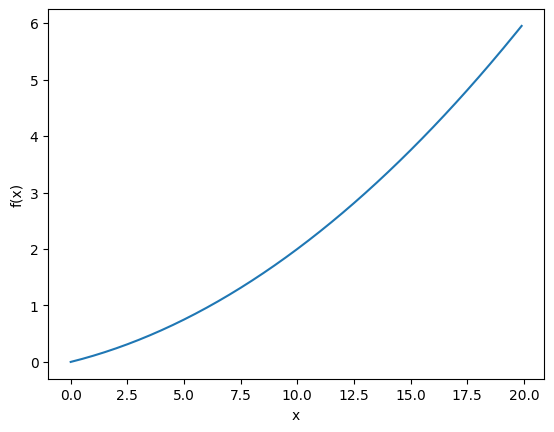

0.1999999999990898
0.2999999999986347


In [5]:
#数值微分
#导数的定义:f'(x)=(f(x+h)-f(x))/h,当h无限趋近于0时,导数就是函数在某一点的斜率
#不好的实现
def numerical_diff_pre(f, x):
    h = 1e-50
    return (f(x+h)-f(x))/h
#h太小,导致计算机计算不了,会变成0

#改进的实现,中心差分,在x+h和x-h两点的差分
def numerical_diff(f, x):
    h = 1e-4
    return (f(x+h)-f(x-h))/(2*h)

#例子
import numpy as np
import matplotlib.pylab as plt

def function_1(x):
    return 0.01*x**2+0.1*x

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x, y)
plt.show()

#求x=5和x=10时的导数
print(numerical_diff(function_1, 5))#0.1999999999990898
print(numerical_diff(function_1, 10))#0.2999999999986347

In [6]:
#偏导数
def numerical_diff(f, x):
    h = 1e-4
    return (f(x+h)-f(x-h))/(2*h)

def function_2(x):
    return x[0]**2+x[1]**2

#求(x0,x1)=(3,4)时,x0的偏导数
def function_tmp1(x0):
    return x0*x0+4.0**2.0

print(numerical_diff(function_tmp1, 3.0))#6.00000000000378

#求(x0,x1)=(3,4)时,x1的偏导数
def function_tmp2(x1):
    return 3.0**2.0+x1*x1

print(numerical_diff(function_tmp2, 4.0))#7.999999999999119

6.00000000000378
7.999999999999119


## 梯度
在刚才的例子中，我们按变量分别计算了 $x_0$ 和 $x_1$ 的偏导数。现在，我们希望一起计算 $x_0$ 和 $x_1$ 的偏导数。比如，我们来考虑求 $x_0 = 3, x_1 = 4$ 时 $(x_0, x_1)$ 的偏导数 $\left( \frac{\partial f}{\partial x_0}, \frac{\partial f}{\partial x_1} \right)$。另外，像 $\left( \frac{\partial f}{\partial x_0}, \frac{\partial f}{\partial x_1} \right)$ 这样的由全部变量的偏导数汇总而成的向量称为梯度（gradient）。梯度可以像下面这样来实现。

In [7]:
#梯度
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)#生成和x形状相同的数组

    for idx in range(x.size):
        tmp_val = x[idx]
        # 计算f(x+h)
        x[idx] = tmp_val+h
        fxh1 = f(x)

        # 计算f(x-h)
        x[idx] = tmp_val-h
        fxh2 = f(x)

        # 计算梯度
        grad[idx] = (fxh1-fxh2)/(2*h)
        x[idx] = tmp_val # 还原值
        
    return grad

import numpy as np
#例子
def function_2(x):
    return x[0]**2+x[1]**2

print(numerical_gradient(function_2, np.array([3.0, 4.0])))#[6. 8.]

#复杂的例子
def function_3(X):
    x, y = X[0], X[1]  # 提取 x 和 y
    return x**2 + 2*y**2 + 3*x*y + 4*x + 5*y + 6

X=np.array([1.0,2.0])
print(numerical_gradient(function_3,X))#受步长影响,梯度有可能不是十分准确

#更复杂的例子
def function_4(X):
    x, y, z = X[0], X[1], X[2]
    return x**3 + y**2 + z**4 + 2*x*y + 3*y*z + 4*x*z + 5*x + 6*y + 7*z + 8

X = np.array([1.0, 2.0, 3.0])  # x = 1, y = 2, z = 3
print(numerical_gradient(function_4,X))

[6. 8.]
[12. 16.]
[ 24.00000001  21.         125.00000012]


## 梯度下降法
根据目的是寻找最小值还是最大值，梯度法的叫法有所不同。严格地讲，寻找最小值的梯度法称为梯度下降法（gradient descent method），寻找最大值的梯度法称为梯度上升法（gradient ascent method）。但是通过反转损失函数的符号，求最小值的问题和求最大值的问题会变成相同的问题，因此“下降”还是“上升”的差异本质上并不重要。一般来说，神经网络（深度学习）中，梯度法主要是指梯度下降法。

现在，我们尝试用数学式来表示梯度法，如式(4.7)所示。

$$
\begin{align}
x_0 &= x_0 - \eta \frac{\partial f}{\partial x_0} \\
x_1 &= x_1 - \eta \frac{\partial f}{\partial x_1}
\end{align}
\tag{4.7}
$$

式(4.7)的$\eta$表示更新量，在神经网络的学习中，称为**学习率**(learning rate)。学习率决定在一次学习中，应该学习多少，以及在多大程度上更新参数。

式(4.7)是表示更新一次的式子，这个步骤会反复执行。也就是说，每一步都按式(4.7)更新变量的值，通过反复执行此步骤，逐渐减小函数值。虽然这里只展示了有两个变量时的更新过程，但是即便增加变量的数量，也可以通过类似的式子(各个变量的偏导数)进行更新。

学习率需要事先确定为某个值，比如0.01或0.001。一般而言，这个值过大或过小，都无法抵达一个“好的位置”。在神经网络的学习中，一般会一边改变学习率的值，一边确认学习是否正确进行了。

下面，我们用Python来实现梯度下降法。如下所示，这个实现很简单。

In [8]:
#梯度下降法
#学习率,学习率决定了一次学习中，应该学习多少，以及在多大程度上更新参数
#学习率需要事先确定为某个值，比如0.01和0.001。一般而言，这个值过大或者过小都无法抵达一个“好的位置”。
#在神经网络学习中，一般会一边改变学习率的值，一边确定学习是否正确进行了。
import numpy as np

def gradient_descent(f,init_x,lr=0.01,step_num=100):
    
    x=init_x

    for i in range(step_num):
        grad=numerical_gradient(f,x)
        x-=lr*grad
        
    return x 
#参数f是要进行最优化的函数，init_x是初始值，lr是学习率learning rate，step_num是梯度法的重复次数。
# numerical_gradient(f,x)会求函数的梯度，用梯度乘以学习率得到的值进行更新操作，有step_num指定重复的次数。

def function_2(x):
    return x[0]**2+x[1]**2

init_x=np.array([-3.0,4.0])
y=gradient_descent(function_2,init_x,lr=0.1,step_num=100)
print("学习率为0.1："+str(y))
z1=gradient_descent(function_2,init_x,lr=0.01,step_num=100)
print("学习率为0.01："+str(z1))
z2=gradient_descent(function_2,init_x,lr=0.001,step_num=100)
print("学习率为0.001："+str(z2))
z3=gradient_descent(function_2,init_x,lr=1,step_num=100)
print("学习率为1："+str(z3))
z4=gradient_descent(function_2,init_x,lr=10,step_num=100)
print("学习率为10："+str(z4))
print("学习率过大")
z5=gradient_descent(function_2,init_x,lr=1e-10,step_num=100)
print("学习率为1e-10："+str(z5))
print("学习率过小")

学习率为0.1：[-6.11110793e-10  8.14814391e-10]
学习率为0.01：[-8.10452420e-11  1.08060323e-10]
学习率为0.001：[-6.63409447e-11  8.84545930e-11]
学习率为1：[-6.63409447e-11  8.84545930e-11]
学习率为10：[-9.70536091e+12  9.58718833e+12]
学习率过大
学习率为1e-10：[-9.70536091e+12  9.58718833e+12]
学习率过小


像学习率这样的参数称为超参数。这是一种和神经网络的参数（权重和偏置）性质不同的参数。相对于神经网络的权重参数是通过训练数据和学习算法自动获得的，学习率这样的超参数则是人工设定的。一般来说，超参数需要尝试多个值，以便找到一种可以使学习顺利进行的设定。

## 神经网络的梯度
神经网络的学习也要求梯度。这里所说的梯度是指损失函数关于权重参数的梯度。比如，有一个只有一个形状为 $2 \times 3$ 的权重 $\boldsymbol{W}$ 的神经网络，损失函数用 $L$ 表示。此时，梯度可以用 $\frac{\partial L}{\partial \boldsymbol{W}}$ 表示。用数学式表示的话，如下所示。

$$
\boldsymbol{W} = \begin{pmatrix}
w_{11} & w_{12} & w_{13} \\
w_{21} & w_{22} & w_{23}
\end{pmatrix} \tag{4.8}
$$

$$
\frac{\partial L}{\partial \boldsymbol{W}} = \begin{pmatrix}
\frac{\partial L}{\partial w_{11}} & \frac{\partial L}{\partial w_{12}} & \frac{\partial L}{\partial w_{13}} \\
\frac{\partial L}{\partial w_{21}} & \frac{\partial L}{\partial w_{22}} & \frac{\partial L}{\partial w_{23}}
\end{pmatrix}
$$

$\frac{\partial L}{\partial \boldsymbol{W}}$ 的元素由各个元素关于 $\boldsymbol{W}$ 的偏导数构成。比如，第 1 行第 1 列的元素 $\frac{\partial L}{\partial w_{11}}$ 表示当 $w_{11}$ 稍微变化时，损失函数 $L$ 会发生多大变化。这里的重点是，$\frac{\partial L}{\partial \boldsymbol{W}}$ 的形状和 $\boldsymbol{W}$ 相同。实际上，式 (4.8) 中的 $\boldsymbol{W}$ 和 $\frac{\partial L}{\partial \boldsymbol{W}}$ 都是 $2 \times 3$ 的形状。

下面，我们以一个简单的神经网络为例，来实现求梯度的代码。为此，我们要实现一个名为 `simpleNet` 的类。

In [9]:
#神经网络的梯度，单层神经网络的实现过程
import os,sys
sys.path.append(os.pardir)
import numpy as np
from common.functions import softmax,cross_entropy_error#导入softmanx函数和交叉熵误差
from common.gradient import numerical_gradient#导入多维数值微分函数

#以一个简单的神经网络为例来实现神经网络的梯度，一层神经网络，输入层两个值，输出层三个值
class simpleNet:
    def __init__(self):
        self.W=np.random.randn(2,3)#用高斯分布进行初始化权重矩阵

    def predict(self,x):#前向传播
        return np.dot(x,self.W)
    
    def loss(self,x,t):#损失函数
        z=self.predict(x)
        y=softmax(z)#y为输出结果，与标签t比较得到交叉熵误差
        loss=cross_entropy_error(y,t)

        return loss

net=simpleNet()
print(net.W)#输出权重矩阵
x=np.array([0.6,0.9])#输入初始值
p=net.predict(x)#神经网络输出结果
print(p)#输出神经网络的输出结果
print(np.argmax(p))#输出最大值的索引,即预测的标签
t=np.array([0,0,1])#正确解的标签
net.loss(x,t)
print(net.loss(x,t))#输出交叉熵误差

#求梯度，需要使损失函数尽可能小，因此需要使用梯度下降法通过改变net.W来改变输出层的数值来减小梯度
def f(W):
    return net.loss(x,t)

dW=numerical_gradient(f,net.W)#求梯度,返回的是一个字典
print(dW)#输出梯度

f=lambda w:net.loss(x,t)#lambda函数,将f(w)赋值给net.loss(x,t)
dW=numerical_gradient(f,net.W)
print(dW)


[[-0.32591858  0.94583801  0.12025563]
 [-1.3883078   1.1436218   0.19828899]]
[-1.44502817  1.59676243  0.25061347]
1
1.614639939781308
[[ 0.02190351  0.45871893 -0.48062244]
 [ 0.03285527  0.68807839 -0.72093366]]
[[ 0.02190351  0.45871893 -0.48062244]
 [ 0.03285527  0.68807839 -0.72093366]]


## 学习算法的实现：  
### 前提：  
神经网络存在合适的权重和偏置，调整权重和偏置以便拟合训练数据的过程称为“学习”、神经网络的学习分为下面四个步骤：  
### 步骤1（mini-batch）：  
从训练数据中随机选出一部分数据，这部分数据称为mini-batch。我们的目标是减小mini-batch的损失函数的值。  
### 步骤2（计算梯度）：  
为了减小mini-batch的损失函数的值，需要求出各个权重参数的梯度。梯度表示损失函数的值减小最多的方向。  
### 步骤3（更新参数）：  
将权重参数沿梯度方向进行微小更新。  
### 步骤4（重复）：  
重复步骤1，步骤2，步骤3。

神经网络的学习按照上面4个步骤进行。这个方法通过梯度下降法更新参数，不过因为这里使用的数据是随机选择的mini batch数据，所以又称为随机梯度下降法（stochastic gradient descent）。“随机”指的是“随机选择的”的意思，因此，随机梯度下降法是“对随机选择的数据进行的梯度下降法”。深度学习的很多框架中，随机梯度下降法一般由一个名为SGD的函数来实现。SGD来源于随机梯度下降法的英文名称的首字母。

## 两层神经网络的类
首先，我们将这个2层神经网络实现为一个名为``TwoLayerNet``的类，实现过程如下所示。

In [10]:
#两层神经网络的类
import os,sys
sys.path.append(os.pardir)
import numpy as np
from common.functions import *
from common.gradient import numerical_gradient#导入多维数值微分函数

class TwoLayerNet:

    def __init__(self,input_size,hidden_size,output_size,weight_init_std=0.01):
        #初始化权重
        self.params={}
        self.params['W1']=weight_init_std*np. random.randn(input_size,hidden_size)
        self.params['b1']=np.zeros(hidden_size)
        self.params['W2']=weight_init_std*np.random.randn(hidden_size,output_size)
        self.params['b2']=np.zeros(output_size)

    def predict(self,x):
        W1,W2=self.params['W1'],self.params['W2']
        b1,b2=self.params['b1'],self.params['b2']

        a1=np.dot(x,W1)+b1
        z1=sigmoid(a1)
        a2=np.dot(z1,W2)+b2
        y=softmax(a2)

        return y
    
    #x:输入数据，t：监督数据
    def loss(self,x,t):
        y=self.predict(x)

        return cross_entropy_error(y,t)
    
    #计算准确率
    def accuracy(self,x,t):
        y=self.predict(x)
        y=np.argmax(y,axis=1)
        t=np.argmax(t,axis=1)

        accuracy=np.sum(y==t)/float(x.shape[0])
        return accuracy

    #计算梯度
    def numerical_gradient(self,x,t):
        loss_W=lambda W:self.loss(x,t)#lambda函数,将f(w)赋值给net.loss(x,t)

        grads={}
        grads['W1']=numerical_gradient(loss_W,self.params['W1'])
        grads['b1']=numerical_gradient(loss_W,self.params['b1'])
        grads['W2']=numerical_gradient(loss_W,self.params['W2'])
        grads['b2']=numerical_gradient(loss_W,self.params['b2'])

        return grads

#例子    
net=TwoLayerNet(input_size=784,hidden_size=100,output_size=10)
print(net.params['W1'].shape)#(784,100)
print(net.params['b1'].shape)#(100,)
print(net.params['W2'].shape)#(100,10)
print(net.params['b2'].shape)#(10,)

x=np.random.randn(100,784)#伪输入数据(100笔)
y=net.predict(x)    
t=np.random.randn(100,10)#伪正确解标签(100笔)

grads=net.numerical_gradient(x,t)#计算梯度

print(grads['W1'].shape)
print(grads['b1'].shape)
print(grads['W2'].shape)
print(grads['b2'].shape)

print(grads['W1'])
print(grads['b1'])
print(grads['W2'])
print(grads['b2'])

(784, 100)
(100,)
(100, 10)
(10,)


(784, 100)
(100,)
(100, 10)
(10,)
[[ 3.94376360e-04  8.64815797e-05  1.83318889e-04 ...  2.06051951e-04
   1.92101335e-05  1.20021966e-04]
 [ 6.82727932e-04  6.72169009e-05 -2.40962612e-04 ... -3.79655403e-04
   2.33682313e-04 -1.62078573e-04]
 [ 5.19474423e-04  2.18519884e-04  4.18272943e-04 ... -2.28317432e-05
   1.06543683e-04 -1.20250767e-04]
 ...
 [ 1.12892970e-03  3.22014153e-04  1.60448321e-05 ... -2.86057400e-05
   3.67569999e-04 -7.03655623e-05]
 [-3.74203490e-05  6.62460131e-05 -1.05895179e-04 ...  3.19925526e-04
  -7.03370717e-05  1.26034765e-04]
 [ 9.62952429e-04  8.42184611e-05 -2.50400793e-04 ... -5.05361109e-05
   6.23602969e-05 -2.14505771e-04]]
[ 1.23437667e-04 -1.32432154e-05  8.86567086e-05  1.10362632e-04
  8.03292100e-05  1.06728790e-04 -1.76384307e-04  4.14993402e-04
  3.91473054e-05 -3.53975145e-04  9.50333812e-06  1.14672183e-05
 -2.09783659e-04 -4.63520113e-04 -1.63922329e-04  5.60212965e-05
  2.83061476e-04  1.28426891e-04 -3.02681189e-04 -1.56659921e-04
 -2.0

### 表4-1 TwoLayerNet类中使用的变量

| 变量   | 说明                                                         |
| ------ | ------------------------------------------------------------ |
| params | 保存神经网络的参数的字典型变量（实例变量）。<br/>`params['W1']`是第1层的权重，`params['b1']`是第1层的偏置。<br/>`params['W2']`是第2层的权重，`params['b2']`是第2层的偏置 |
| grads  | 保存梯度的字典型变量（`numerical_gradient()`方法的返回值）。<br/>`grads['W1']`是第1层权重的梯度，`grads['b1']`是第1层偏置的梯度。<br/>`grads['W2']`是第2层权重的梯度，`grads['b2']`是第2层偏置的梯度 |

### 表4-2 TwoLayerNet类的方法

| 方法                                  | 说明                                                         |
| ------------------------------------- | ------------------------------------------------------------ |
| `__init__(self, input_size, hidden_size, output_size)` | 进行初始化。<br/>参数从头开始依次表示输入层的神经元数、隐藏层的神经元数、输出层的神经元数 |
| `predict(self, x)`                    | 进行识别（推理）。<br/>参数`x`是图像数据                     |
| `loss(self, x, t)`                    | 计算损失函数的值。<br/>参数`x`是图像数据，`t`是正确解标签（后面3个方法的参数也一样） |
| `accuracy(self, x, t)`                | 计算识别精度                                                 |
| `numerical_gradient(self, x, t)`      | 计算权重参数的梯度                                           |
| `gradient(self, x, t)`                | 计算权重参数的梯度。<br/>`numerical_gradient()`的高速版，将在下一章实现 |

## mini-batch的实现
神经网络的学习的实现使用的是前面介绍过的mini-batch学习。所谓mini-batch学习，就是从训练数据中随机选择一部分数据（称为mini-batch），再以这些mini-batch为对象，使用梯度法更新参数的过程。下面，我们就以``TwoLayerNet``类为对象，使用MNIST数据集进行学习。

迭代次数: 0, 损失值: 2.291827602925329
迭代次数: 1000, 损失值: 0.7657866688257283
迭代次数: 2000, 损失值: 0.44604061154622854
迭代次数: 3000, 损失值: 0.33425844611443806
迭代次数: 4000, 损失值: 0.34335700018374654
迭代次数: 5000, 损失值: 0.2362825272449503
迭代次数: 6000, 损失值: 0.15285427889583822
迭代次数: 7000, 损失值: 0.24369360065366893
迭代次数: 8000, 损失值: 0.3039417041738858
迭代次数: 9000, 损失值: 0.13550188867844887


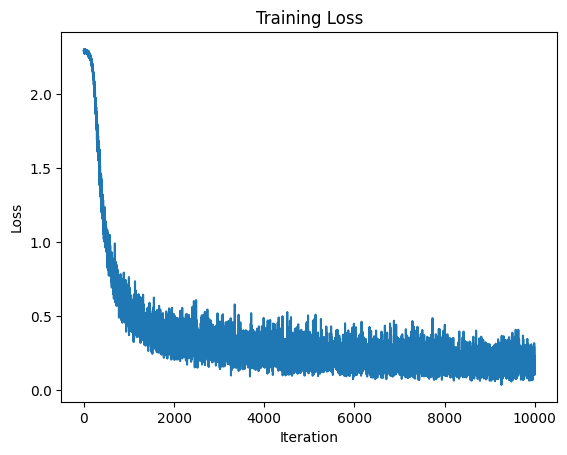

In [11]:
#mini-batch的实现
import os,sys
sys.path.append(os.pardir)#导入上级目录的文件
import numpy as np
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet
import matplotlib.pyplot as plt

(x_train,t_train),(x_test,t_test)=load_mnist(normalize=True,flatten=True,one_hot_label=True)

train_loss_list=[]

#超参数
iters_num=10000
train_size=x_train.shape[0]
batch_size=100
learning_rate=0.1
network=TwoLayerNet(input_size=784,hidden_size=50,output_size=10)

for i in range(iters_num):
    #获取mini-batch
    batch_mask=np.random.choice(train_size,batch_size)
    x_batch=x_train[batch_mask]
    t_batch=t_train[batch_mask]

    #计算梯度
    #grad=network.numerical_gradient(x_batch,t_batch)
    grad=network.gradient(x_batch,t_batch) #高速版！

    #更新参数
    for key in ('W1','b1','W2','b2'):
        network.params[key]-=learning_rate*grad[key]

    #记录学习过程
    loss=network.loss(x_batch,t_batch)
    train_loss_list.append(loss)

    # 每1000次迭代打印一次损失
    if i % 1000 == 0:
        print(f"迭代次数: {i}, 损失值: {loss}")

# 绘制学习曲线
plt.plot(train_loss_list)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()


## 基于测试数据的评价
神经网络的学习中，必须确认是否能够正确识别训练数据以外的其他数据，即确认是否会发生过拟合。过拟合是指，虽然训练数据中的数字图像能被正确辨别，但是不在训练数据中的数字图像却无法被识别的现象。神经网络学习的最初目标是掌握泛化能力，因此，要评价神经网络的泛化能力，就必须使用不包含在训练数据中的数据。下面的代码在进行学习的
过程中，会定期地对训练数据和测试数据记录识别精度。这里，每经过一个epoch，我们都会记录下训练数据和测试数据的识别精度。

epoch是一个单位。一个 epoch表示学习中所有训练数据均被使用过一次时的更新次数。比如，对于 10000笔训练数据，用大小为 100笔数据的mini-batch进行学习时，重复随机梯度下降法 100次，所有的训练数据就都被“看过”了。此时，100次就是一个 epoch。

Epoch 0 | 训练准确率: 0.1044 | 测试准确率: 0.1028
Epoch 1 | 训练准确率: 0.7913 | 测试准确率: 0.7938
Epoch 2 | 训练准确率: 0.8770 | 测试准确率: 0.8785
Epoch 3 | 训练准确率: 0.8978 | 测试准确率: 0.9004
Epoch 4 | 训练准确率: 0.9080 | 测试准确率: 0.9102
Epoch 5 | 训练准确率: 0.9141 | 测试准确率: 0.9177
Epoch 6 | 训练准确率: 0.9191 | 测试准确率: 0.9220
Epoch 7 | 训练准确率: 0.9239 | 测试准确率: 0.9252
Epoch 8 | 训练准确率: 0.9273 | 测试准确率: 0.9301
Epoch 9 | 训练准确率: 0.9315 | 测试准确率: 0.9322
Epoch 10 | 训练准确率: 0.9345 | 测试准确率: 0.9357
Epoch 11 | 训练准确率: 0.9371 | 测试准确率: 0.9364
Epoch 12 | 训练准确率: 0.9398 | 测试准确率: 0.9387
Epoch 13 | 训练准确率: 0.9412 | 测试准确率: 0.9415
Epoch 14 | 训练准确率: 0.9436 | 测试准确率: 0.9415
Epoch 15 | 训练准确率: 0.9446 | 测试准确率: 0.9421
Epoch 16 | 训练准确率: 0.9476 | 测试准确率: 0.9440


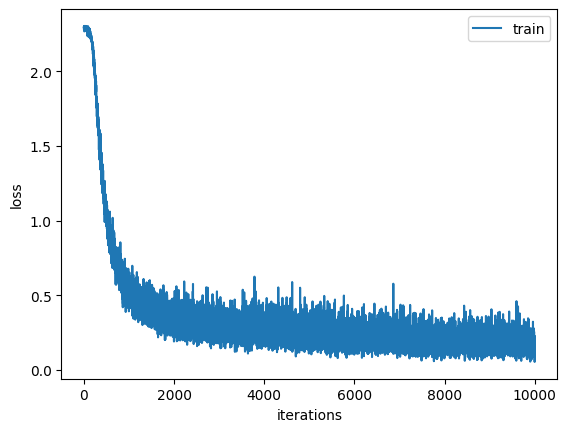

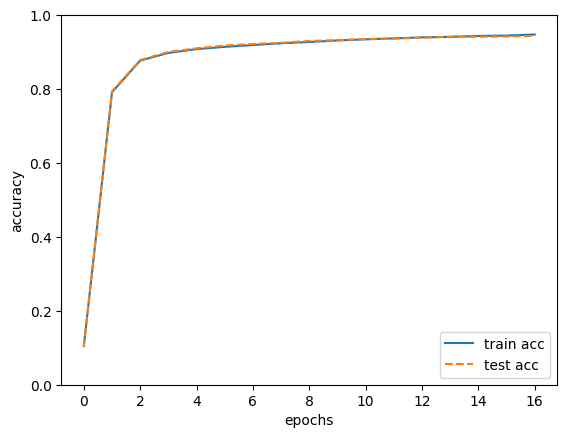

In [12]:
import os,sys
sys.path.append(os.pardir)#导入上级目录的文件
import numpy as np
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet
import matplotlib.pyplot as plt

(x_train,t_train),(x_test,t_test)=load_mnist(normalize=True,flatten=True,one_hot_label=True)

train_loss_list=[]
train_acc_list=[]
test_acc_list=[]
#平均每个epoch的重复次数
iter_per_epoch=max(train_size/batch_size,1)

#超参数
iters_num=10000
batch_size=100
learning_rate=0.1

network=TwoLayerNet(input_size=784,hidden_size=50,output_size=10)

for i in range(iters_num):
    #获取mini-batch
    batch_mask=np.random.choice(train_size,batch_size)
    x_batch=x_train[batch_mask]
    t_batch=t_train[batch_mask]

    #计算梯度
    # grad=network.numerical_gradient(x_batch,t_batch)
    grad=network.gradient(x_batch,t_batch) #高速版！

    #更新参数
    for key in network.params.keys():
        network.params[key]-=learning_rate*grad[key]

    loss=network.loss(x_batch,t_batch)
    train_loss_list.append(loss)

    # 计算每个epoch的识别精度
    if i % iter_per_epoch == 0:
        # 计算准确率
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
    
        # 记录准确率
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
    
        # 计算当前 epoch 数
        epoch = i // iter_per_epoch
        # 格式化输出，保留4位小数并显示 epoch 信息
        print(f"Epoch {int(epoch)} | 训练准确率: {train_acc:.4f} | 测试准确率: {test_acc:.4f}")

# 绘制图像
plt.plot(train_loss_list,label="train")
plt.xlabel("iterations")
plt.ylabel("loss")
plt.legend()
plt.show()

# 绘制准确率曲线
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')#显示图例，位置在右下角
plt.show()


## 小结  
- 机器学习中使用的数据集分为训练数据和测试数据。  
- 神经网络用训练数据进行学习，并用测试数据评价学习到的模型的泛化能力。  
- 神经网络的学习以损失函数为指标，更新权重参数，以使损失函数的值减小。  
- 利用某个给定的微小值的差分求导数的过程，称为数值微分。  
- 利用数值微分，可以计算权重参数的梯度。  
- 数值微分虽然费时间，但是实现起来很简单。下一章要实现的稍微复杂一点的误差反向传播法可以高速地计算梯度。